In [19]:
#A test notebook for sorting out api data aquisition

In [20]:
import sys
print(sys.executable)

/home/djmead/Documents/Projects/Financial/.venv/bin/python


In [ ]:
from fredapi import Fred
import pandas as pd
#import os
import keyring#, getpass
#import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
service = "fred"
api_key = keyring.get_password(service, "api_key")
#api_secret = keyring.get_password(service, "ALPACA_SECRET_KEY")

print(f"API Key: {api_key[:3]}")

API Key: b7b


In [5]:
fred = Fred(api_key=api_key)
unemployment_data = fred.get_series('UNRATE', observation_start='2023-01-01', observation_end='2026-07-31')
print("--- Unemployment Rate Series ---")
print(unemployment_data.tail(24))

--- Unemployment Rate Series ---
2024-08-01    4.2
2024-09-01    4.1
2024-10-01    4.1
2024-11-01    4.2
2024-12-01    4.1
2025-01-01    4.0
2025-02-01    4.2
2025-03-01    4.2
2025-04-01    4.2
2025-05-01    4.3
2025-06-01    4.1
2025-07-01    4.3
2025-08-01    4.3
2025-09-01    4.4
2025-10-01    NaN
2025-11-01    4.5
2025-12-01    4.4
2026-01-01    4.3
2026-02-01    4.4
2026-03-01    4.3
2026-04-01    4.3
2026-05-01    4.3
2026-06-01    4.2
2026-07-01    4.1
dtype: float64


In [6]:
gdp = fred.get_series('GDPC1', observation_start='2023-01-01')
cpi = fred.get_series('CPIAUCSL', observation_start='2023-01-01')
economic_df = pd.DataFrame({'Real_GDP': gdp, 'CPI': cpi})
print("\n--- Combined Economic DataFrame ---")
print(economic_df)#.tail())


--- Combined Economic DataFrame ---
             Real_GDP      CPI
2023-01-01  22439.607  300.420
2023-02-01        NaN  301.450
2023-03-01        NaN  301.821
2023-04-01  22580.499  302.845
2023-05-01        NaN  303.334
2023-06-01        NaN  304.014
2023-07-01  22840.989  304.609
2023-08-01        NaN  306.082
2023-09-01        NaN  307.276
2023-10-01  23033.780  307.696
2023-11-01        NaN  308.148
2023-12-01        NaN  308.741
2024-01-01  23082.119  309.698
2024-02-01        NaN  310.967
2024-03-01        NaN  312.345
2024-04-01  23286.508  313.023
2024-05-01        NaN  313.175
2024-06-01        NaN  313.044
2024-07-01  23478.570  313.569
2024-08-01        NaN  314.062
2024-09-01        NaN  314.732
2024-10-01  23586.542  315.631
2024-11-01        NaN  316.528
2024-12-01        NaN  317.604
2025-01-01  23548.210  318.961
2025-02-01        NaN  319.679
2025-03-01        NaN  319.785
2025-04-01  23770.976  320.302
2025-05-01        NaN  320.620
2025-06-01        NaN  321.435
20

In [7]:
# 3. Search for a specific data series ID code
search_results = fred.search('inflation')
print("\n--- Search Results for 'inflation' ---")
print(search_results[['title', 'units']].head())


--- Search Results for 'inflation' ---
                                                             title    units
series id                                                                  
DFII10           Market Yield on U.S. Treasury Securities at 10...  Percent
FII10            Market Yield on U.S. Treasury Securities at 10...  Percent
WFII10           Market Yield on U.S. Treasury Securities at 10...  Percent
RIFLGFCY10XIINA  Market Yield on U.S. Treasury Securities at 10...  Percent
T10YIE                            10-Year Breakeven Inflation Rate  Percent


In [ ]:
sns.scatterplot(data=economic_df, x='Real_GDP', y='CPI')
plt.show()

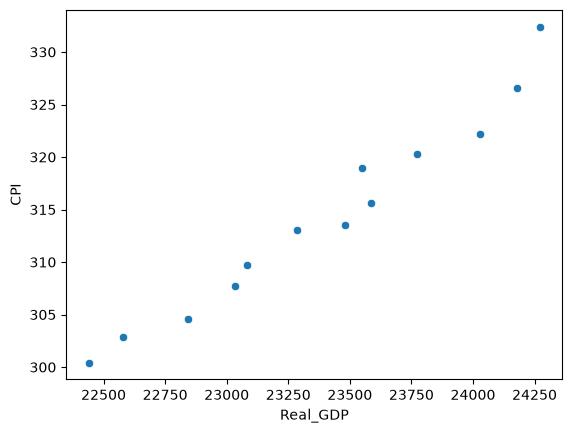

In [11]:
23452/902/4

#with open("assets_us_equity.json", "w") as f:
#    json.dump(resp_json, f, indent=4)

6.5